In [1]:
!pip install pandas numpy matplotlib seaborn --quiet

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")
sns.set_palette("Set2")

df = pd.read_csv("most_subscribed_youtube_channels.csv")
df.head()


,rank,Youtuber,subscribers,video views,video count,category,started
0,1,T-Series,"222,000,000","198,459,090,822","17,317",Music,2006
1,2,YouTube Movies,"154,000,000",0,0,Film & Animation,2015
2,3,Cocomelon - Nursery Rhymes,"140,000,000","135,481,339,848",786,Education,2006
3,4,SET India,"139,000,000","125,764,252,686","91,271",Shows,2006
4,5,Music,"116,000,000",0,0,NaN,2013


In [3]:
df.info()
df.isnull().sum()


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   rank         1000 non-null   int64
 1   Youtuber     1000 non-null   str  
 2   subscribers  1000 non-null   str  
 3   video views  1000 non-null   str  
 4   video count  1000 non-null   str  
 5   category     973 non-null    str  
 6   started      1000 non-null   int64
dtypes: int64(2), str(5)
memory usage: 54.8 KB


rank            0
Youtuber        0
subscribers     0
video views     0
video count     0
category       27
started         0
dtype: int64

In [4]:
df.dropna(inplace=True)

In [5]:
def toInt(x : str | None):
    x = str(x).replace(",", "").strip()
    if (not x):
        return np.nan
    return int(x)

cols = ['subscribers', "video views", "video count"]

for col in cols:
    df[col] = df[col].apply(toInt)

In [6]:
df.describe()

,rank,subscribers,video views,video count,started
count,973.000000,9.730000e+02,9.730000e+02,973.000000,973.000000
mean,500.763618,2.036639e+07,9.306726e+09,8776.802672,2012.267215
std,287.475423,1.538813e+07,1.218412e+10,29733.093888,3.973747
min,1.000000,1.090000e+07,0.000000e+00,0.000000,1970.000000
25%,252.000000,1.270000e+07,3.631748e+09,347.000000,2009.000000
50%,501.000000,1.550000e+07,6.165703e+09,899.000000,2013.000000
75%,748.000000,2.200000e+07,1.147036e+10,3150.000000,2015.000000
max,1000.000000,2.220000e+08,1.984591e+11,329711.000000,2021.000000


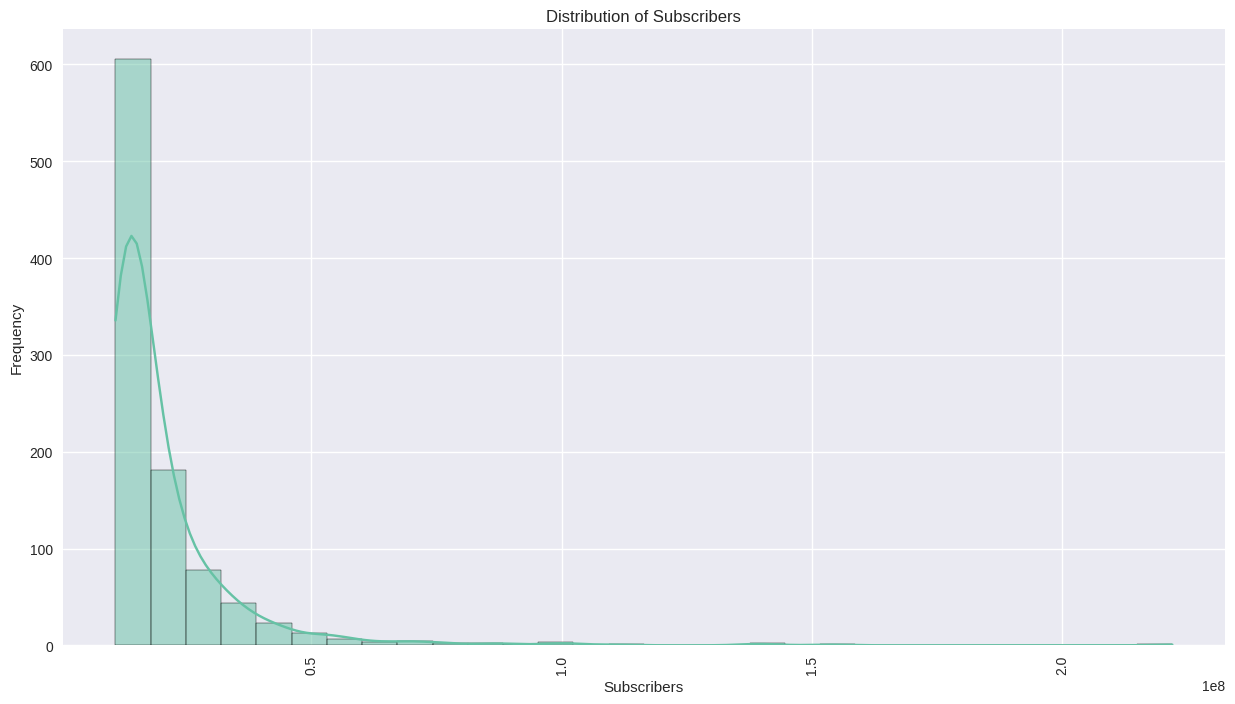

In [7]:
# Distribution of Subscribers
plt.figure(figsize=(15, 8))
sns.histplot(df['subscribers'], bins=30, kde=True)
plt.title("Distribution of Subscribers")
plt.xlabel("Subscribers", )
plt.ylabel("Frequency")
plt.xticks(rotation=90)
plt.show()


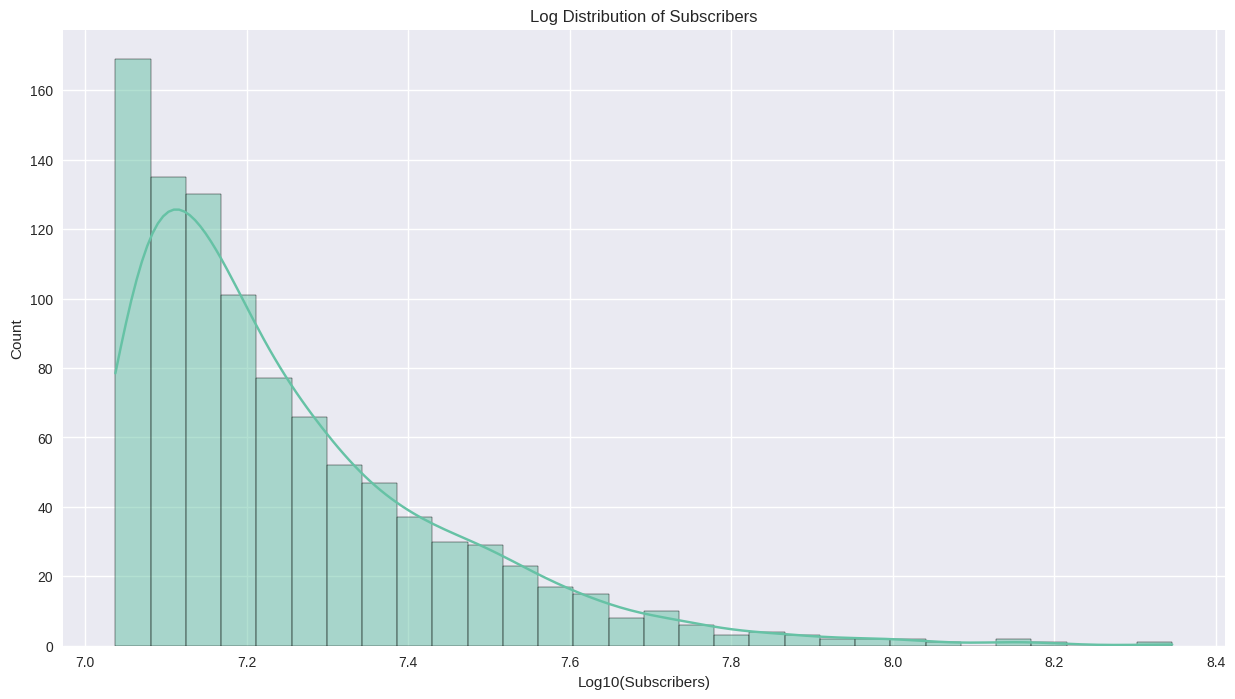

In [8]:
# Log Scale Subscriber Distribution
plt.figure(figsize=(15, 8))
sns.histplot(np.log10(df['subscribers']), bins=30, kde=True)
plt.title("Log Distribution of Subscribers")
plt.xlabel("Log10(Subscribers)")
plt.show()


/home/larson/College Stuff/SMA/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10047 (\N{BLACK FLORETTE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


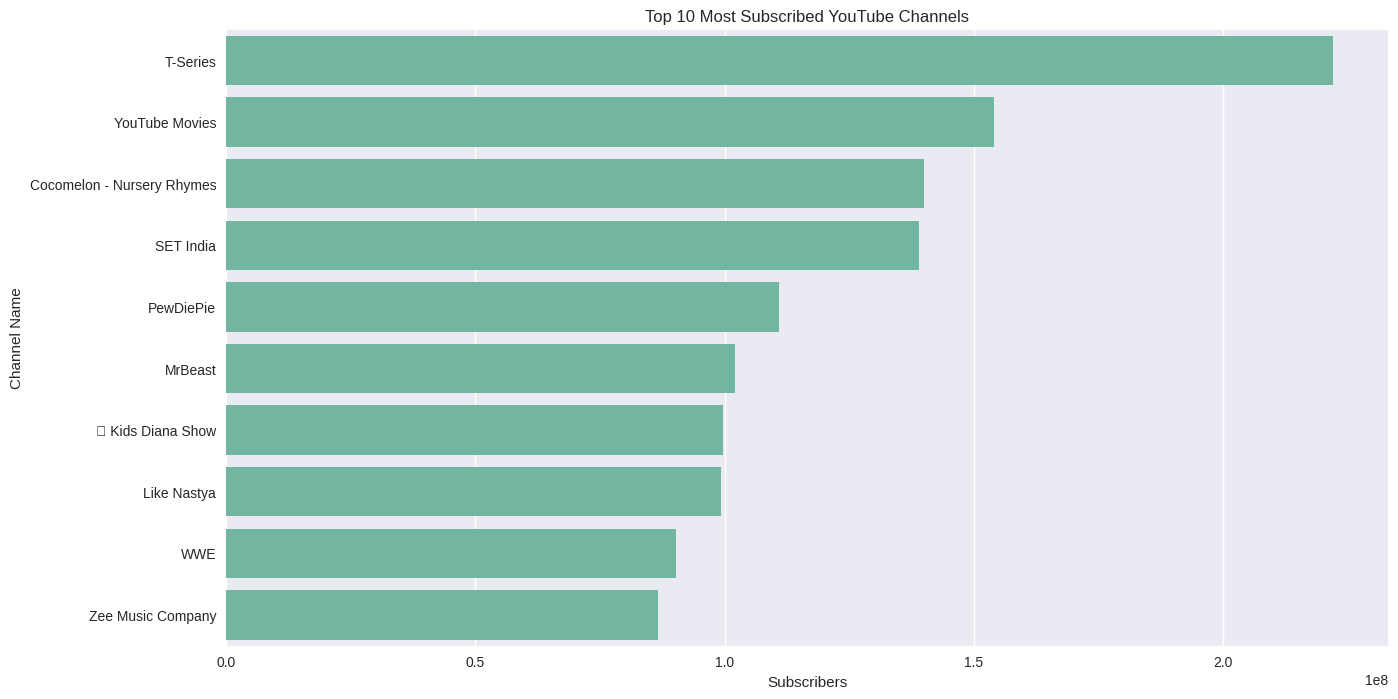

In [9]:
# Top 10 Channels by Subscribers

top10 = df.sort_values("subscribers", ascending=False).head(10)

plt.figure(figsize=(15, 8))

sns.barplot(
    x="subscribers",
    y="Youtuber",
    data=top10,
    order=top10.sort_values("subscribers", ascending=False)["Youtuber"]
)

plt.title("Top 10 Most Subscribed YouTube Channels")
plt.xlabel("Subscribers")
plt.ylabel("Channel Name")
plt.show()



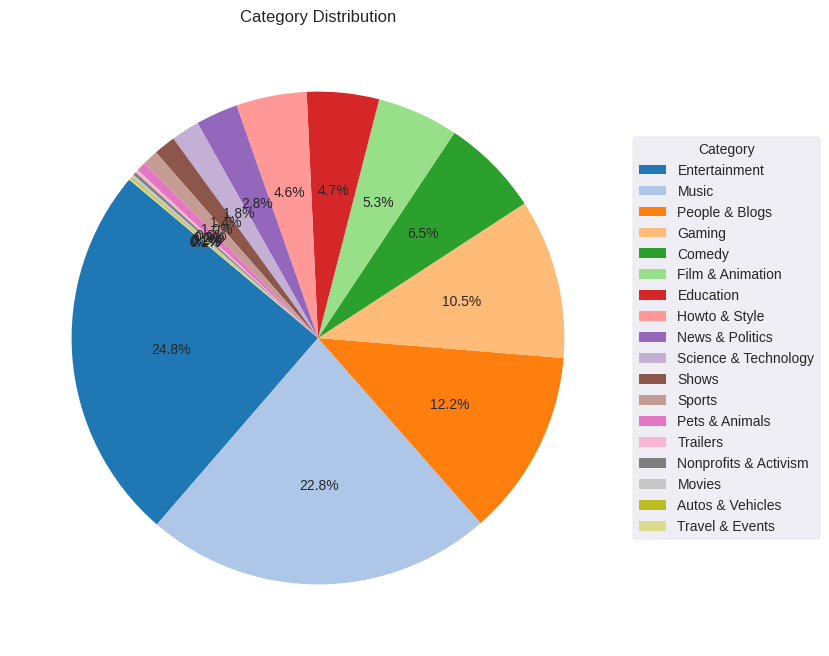

In [10]:
# Category Distribution
plt.figure(figsize=(15, 8))

category_counts = df['category'].value_counts()

colors = plt.cm.tab20.colors  # up to 20 unique colors

wedges, texts, autotexts = plt.pie(
    category_counts,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors[:len(category_counts)]
)

plt.legend(
    wedges,
    category_counts.index,
    title="Category",
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    frameon=True
)

plt.title("Category Distribution")
plt.ylabel("")
plt.show()



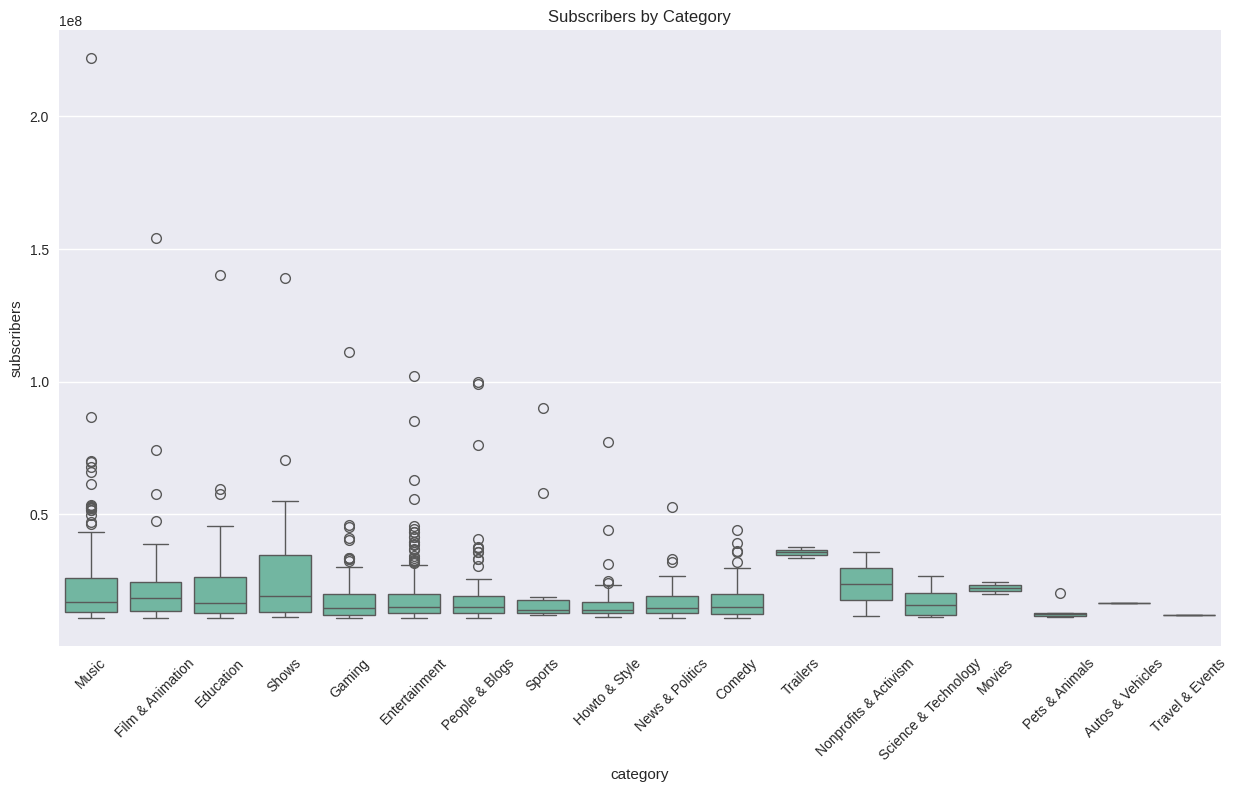

In [11]:
# Subscribers by Category (Boxplot)
plt.figure(figsize=(15, 8))
sns.boxplot(x='category', y='subscribers', data=df)
plt.xticks(rotation=45)
plt.title("Subscribers by Category")
plt.show()


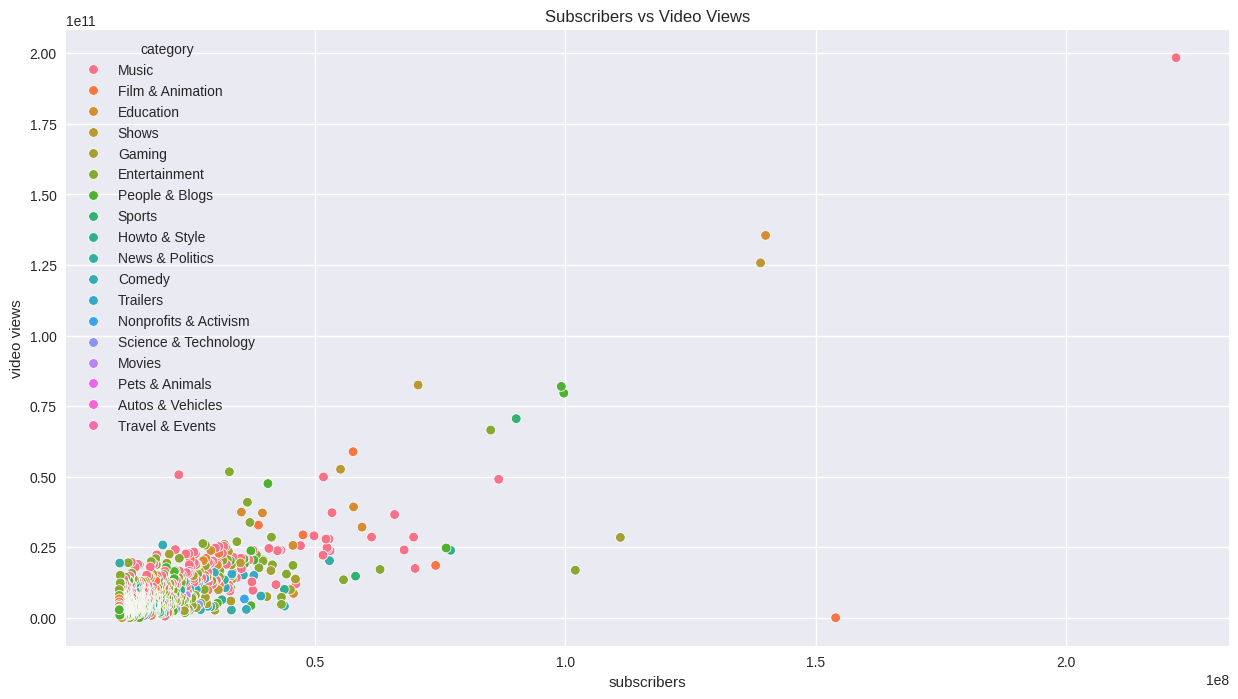

In [12]:
# Video Views vs Subscribers
plt.figure(figsize=(15, 8))
sns.scatterplot(
    x='subscribers',
    y='video views',
    hue='category',
    data=df
)
plt.title("Subscribers vs Video Views")
plt.show()


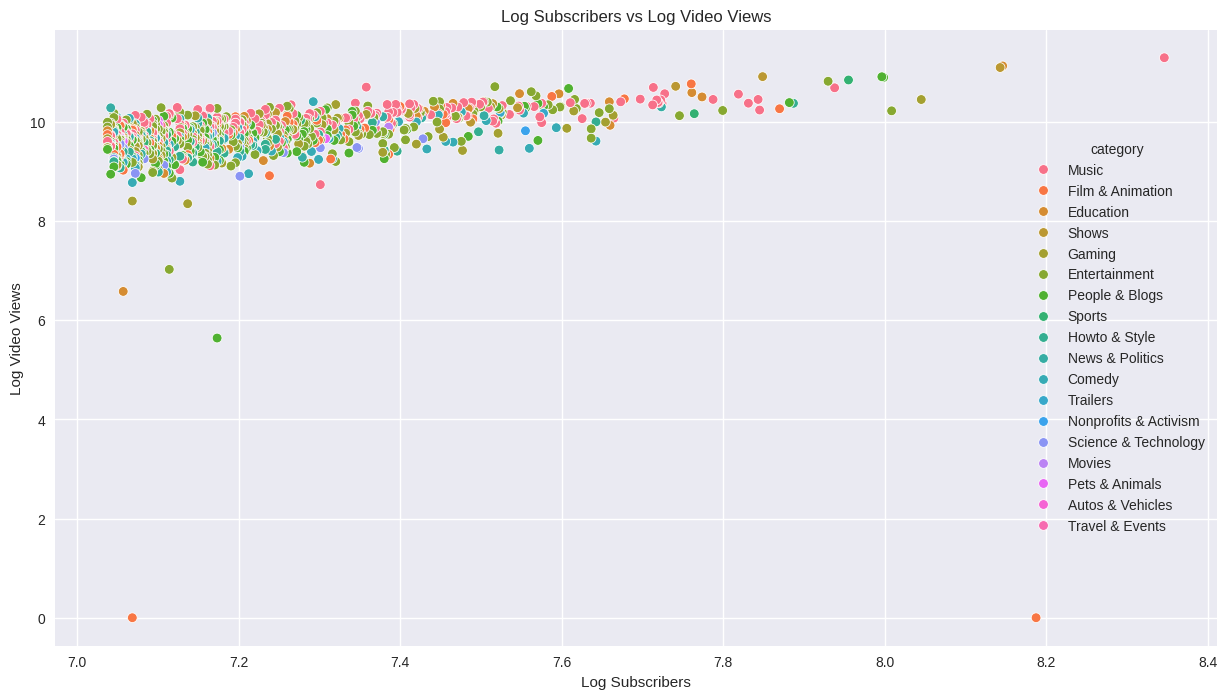

In [13]:
# Log-Scale Scatter (Cleaner)
plt.figure(figsize=(15, 8))
sns.scatterplot(
    x=np.log10(df['subscribers']),
    y=np.log10(df['video views'] + 1),
    hue=df['category']
)
plt.title("Log Subscribers vs Log Video Views")
plt.xlabel("Log Subscribers")
plt.ylabel("Log Video Views")
plt.show()


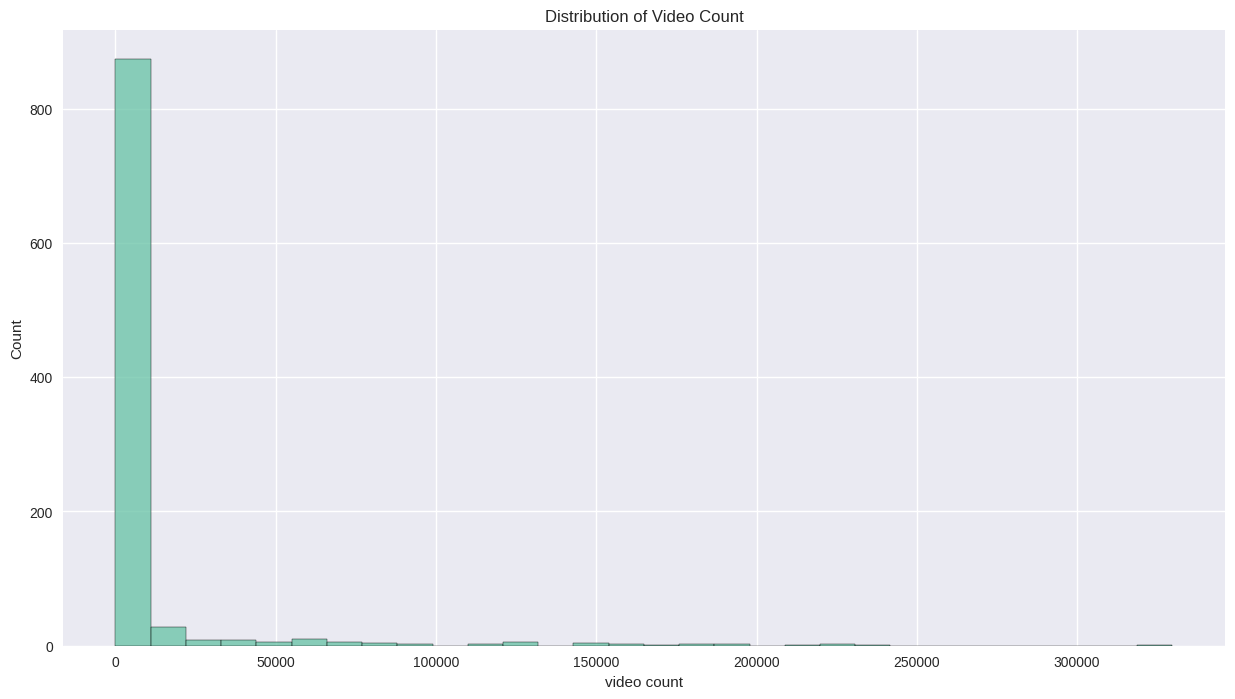

In [14]:
# Upload Count Distribution
plt.figure(figsize=(15, 8))
sns.histplot(df['video count'], bins=30)
plt.title("Distribution of Video Count")
plt.show()


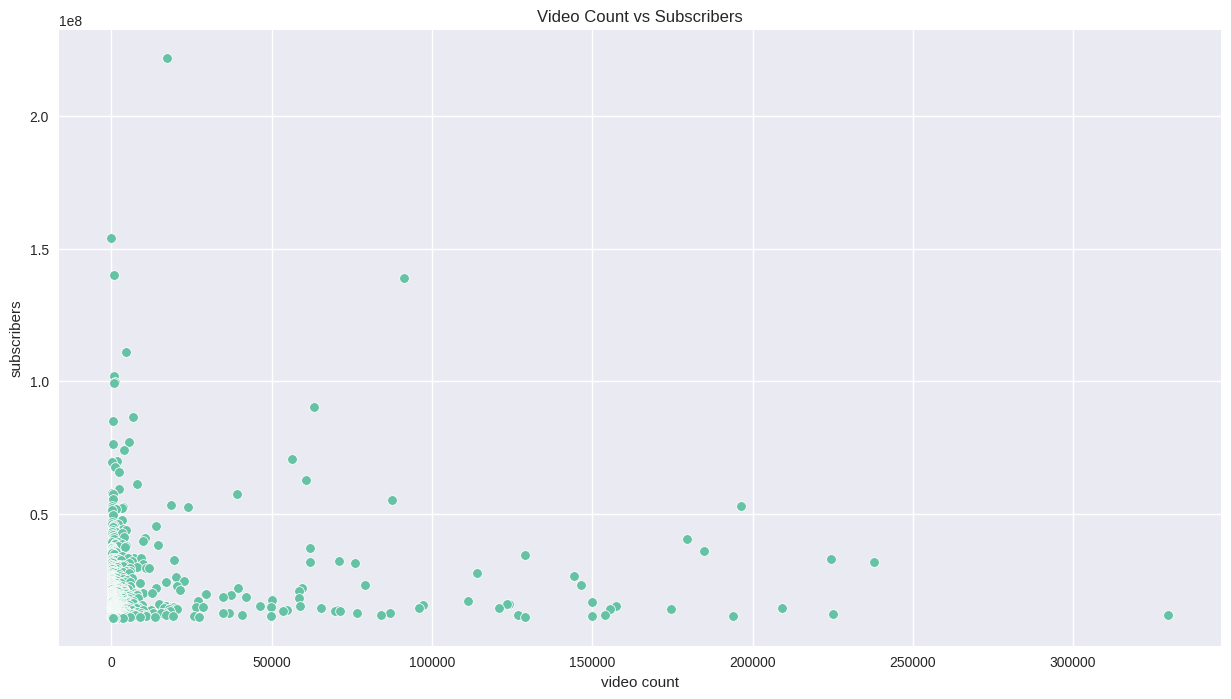

In [15]:
# Video Count vs Subscribers
plt.figure(figsize=(15, 8))
sns.scatterplot(
    x='video count',
    y='subscribers',
    data=df
)
plt.title("Video Count vs Subscribers")
plt.show()


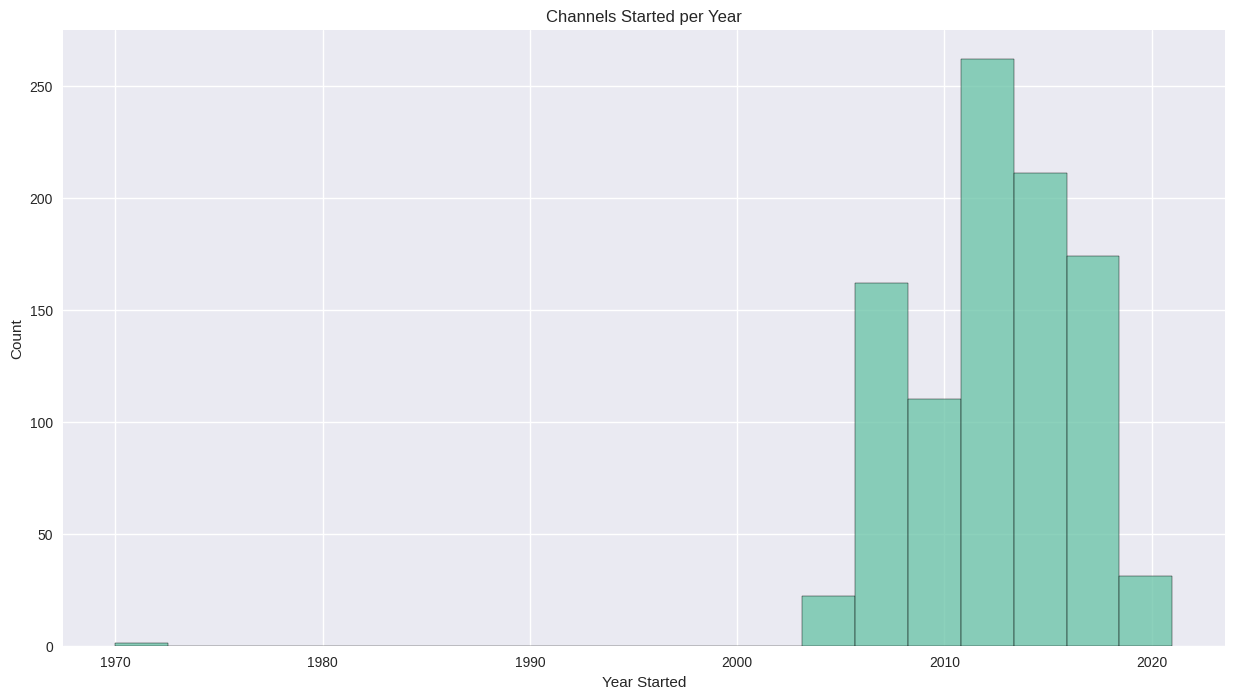

In [16]:
# Channels Started per Year
plt.figure(figsize=(15, 8))
sns.histplot(df['started'], bins=20)
plt.title("Channels Started per Year")
plt.xlabel("Year Started")
plt.show()


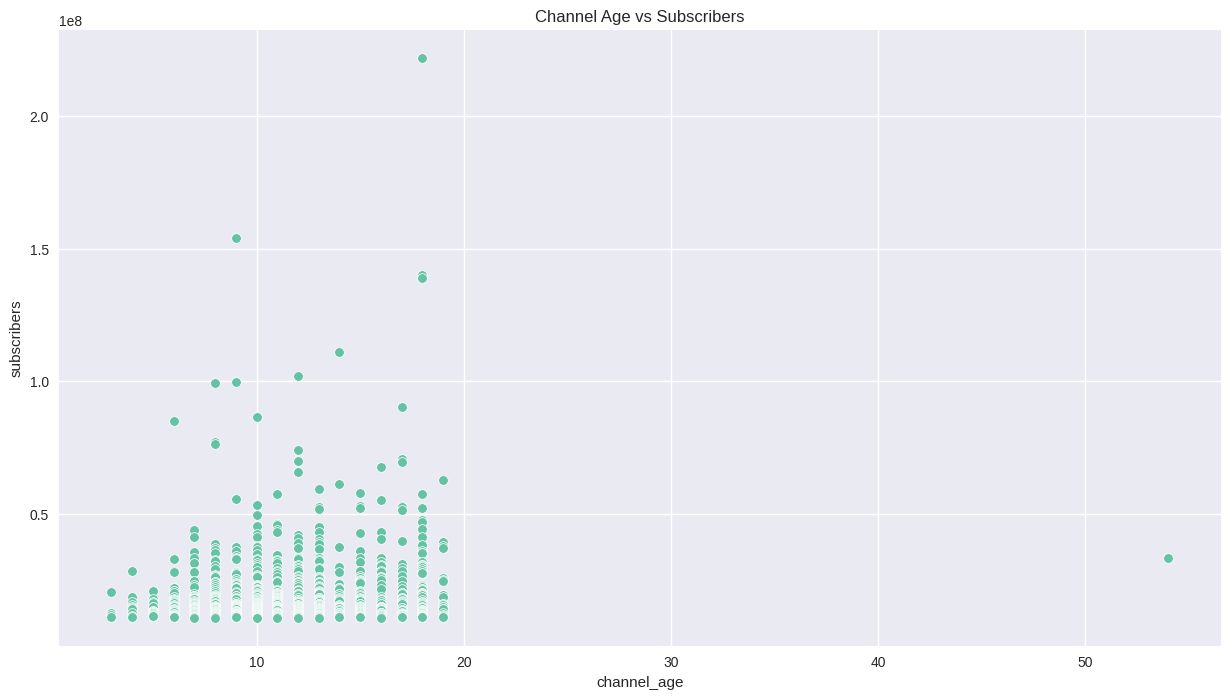

In [17]:
# Subscribers vs Channel Age
df['channel_age'] = 2024 - df['started']

plt.figure(figsize=(15, 8))
sns.scatterplot(
    x='channel_age',
    y='subscribers',
    data=df
)
plt.title("Channel Age vs Subscribers")
plt.show()


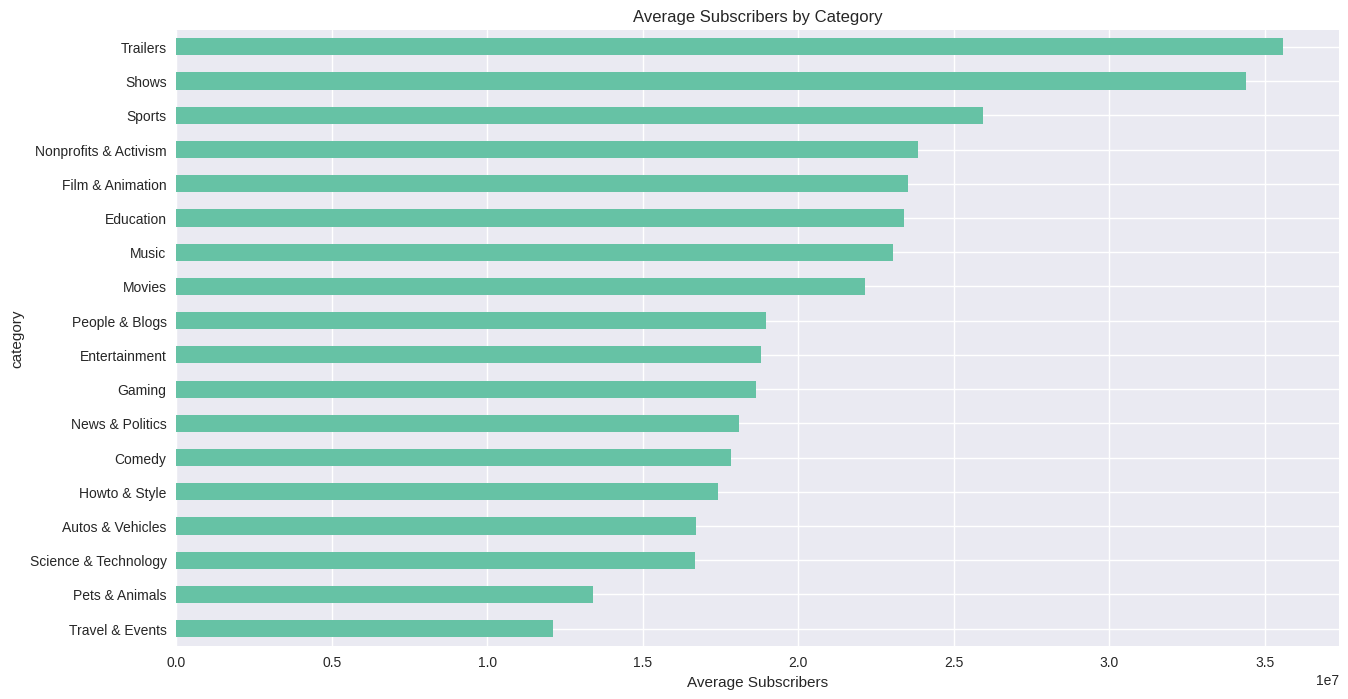

In [18]:
# Average Subscribers by Categoryavg_subs = df.groupby('category')['subscribers'].mean().sort_values()

avg_subs = df.groupby('category')['subscribers'].mean().sort_values()

plt.figure(figsize=(15, 8))
avg_subs.plot(kind='barh')
plt.title("Average Subscribers by Category")
plt.xlabel("Average Subscribers")
plt.show()


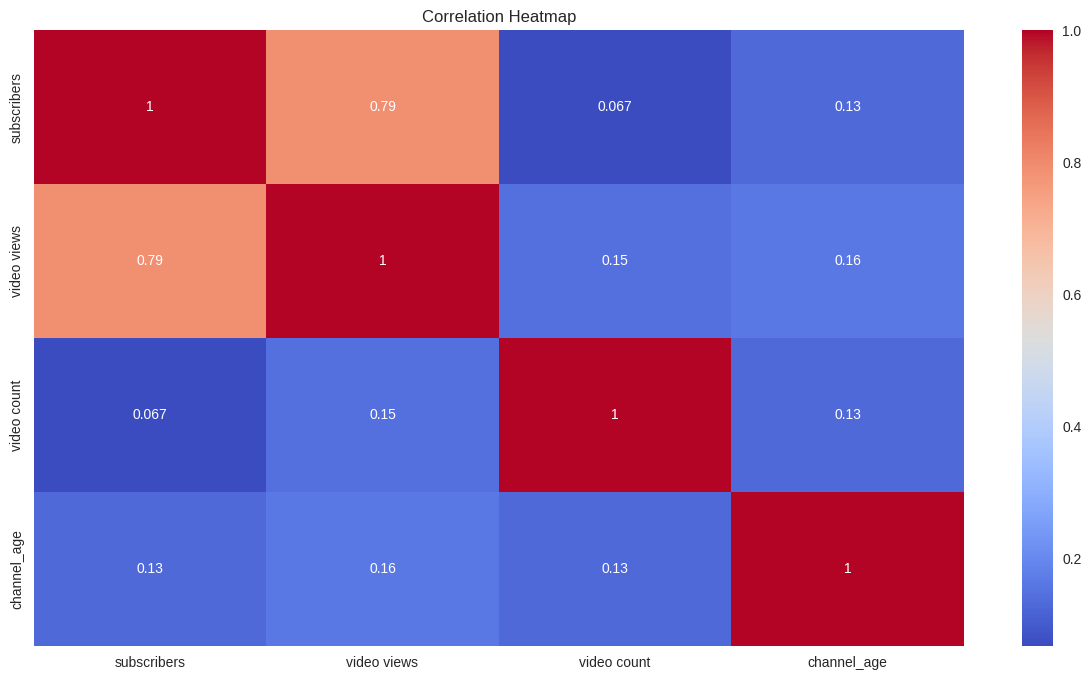

In [19]:
# Correlation Heatmap
plt.figure(figsize=(15, 8))
sns.heatmap(
    df[['subscribers','video views','video count','channel_age']].corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Heatmap")
plt.show()
